## 1. Introduction

In [129]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/silver-prices-10-year-data-and-2026-forecast/silver_prices_data.csv
/kaggle/input/silver-prices-10-year-data-and-2026-forecast/silver_price_forecast_2026.csv


In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
data_filepath = "/kaggle/input/silver-prices-10-year-data-and-2026-forecast/silver_prices_data.csv"
forecast_filepath = "/kaggle/input/silver-prices-10-year-data-and-2026-forecast/silver_price_forecast_2026.csv"

data = pd.read_csv(data_filepath)
forecast = pd.read_csv(forecast_filepath)

In [132]:
data['Date'] = pd.to_datetime(data["Date"])
data['Year'] = data['Date'].dt.year

## 2. EDA


In [133]:
print(f"Data shape {data.shape}")
print(f"Forecast shape {forecast.shape}")

Data shape (2513, 8)
Forecast shape (85, 4)


In [134]:
data.tail()

,Date,Price,Close,High,Low,Open,Volume,Year
2508,2026-01-09,78.884003,79.974998,76.699997,76.699997,254,NaN,2026
2509,2026-01-12,84.610001,85.824997,82.000000,82.000000,575,NaN,2026
2510,2026-01-13,85.876999,88.610001,84.589996,84.904999,341,NaN,2026
2511,2026-01-14,90.869003,93.000000,88.705002,89.349998,470,NaN,2026
2512,2026-01-15,91.875999,92.419998,86.129997,90.824997,470,NaN,2026


In [135]:
forecast.head()

,Date,Predicted_Price,Lower_Bound,Upper_Bound
0,2026-01-02,52.43,48.38,56.64
1,2026-01-05,52.64,48.49,56.84
2,2026-01-06,52.63,48.75,57.01
3,2026-01-07,52.67,48.39,56.62
4,2026-01-08,52.55,48.18,56.60


The provided forecast dataset contains model-generated predictions and confidence intervals rather than observed ground-truth values; therefore, it was not used for training or evaluation.sns.lineplot(x="Year", y="Sales", data=df)

In [136]:
data.describe()

,Date,Price,Close,High,Low,Open,Volume,Year
count,2513,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,0.0,2513.000000
mean,2021-01-16 19:25:31.396737024,22.810332,22.979758,22.646283,22.812519,1777.771190,NaN,2020.543971
min,2016-01-19 00:00:00,11.735000,12.205000,11.735000,12.070000,0.000000,NaN,2016.000000
25%,2018-07-20 00:00:00,16.834000,16.910000,16.764999,16.844999,10.000000,NaN,2018.000000
50%,2021-01-19 00:00:00,21.402000,21.590000,21.065001,21.330000,49.000000,NaN,2021.000000
75%,2023-07-19 00:00:00,25.514999,25.719999,25.275000,25.514999,177.000000,NaN,2023.000000
max,2026-01-15 00:00:00,91.875999,93.000000,88.705002,90.824997,131415.000000,NaN,2026.000000
std,NaN,8.847649,8.998840,8.669933,8.816571,10141.050503,NaN,2.877916


In [137]:
data.drop(columns='Volume', inplace=True)
data.head()

,Date,Price,Close,High,Low,Open,Year
0,2016-01-19,14.110,14.110,14.065,14.065,3,2016
1,2016-01-20,14.147,14.147,14.147,14.147,1,2016
2,2016-01-21,14.083,14.083,14.083,14.083,2,2016
3,2016-01-22,14.043,14.290,14.043,14.290,7,2016
4,2016-01-25,14.240,14.240,14.095,14.095,8,2016


In [138]:
print(data.duplicated().sum())
print(data.isna().sum())

0
Date     0
Price    0
Close    0
High     0
Low      0
Open     0
Year     0
dtype: int64


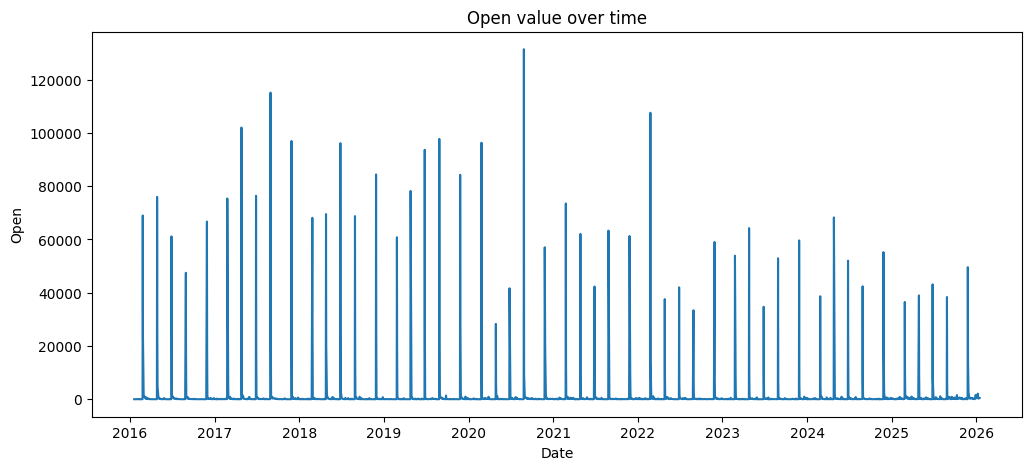

In [139]:
plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Open"])
plt.title("Open value over time")
plt.xlabel("Date")
plt.ylabel("Open")
plt.show()

In [140]:
print(f"Open min {data['Open'].min()}, Open Max {data['Open'].max()}")

Open min 0, Open Max 131415


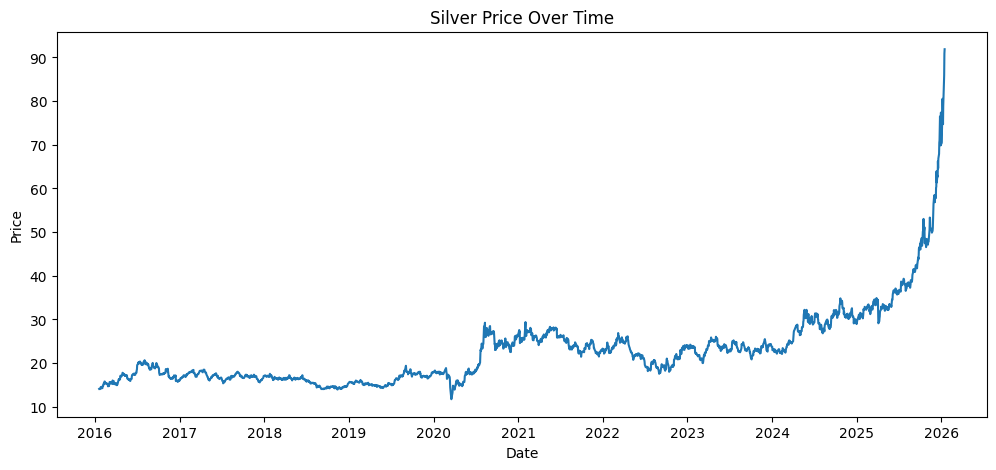

In [141]:
plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Price"])
plt.title("Silver Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

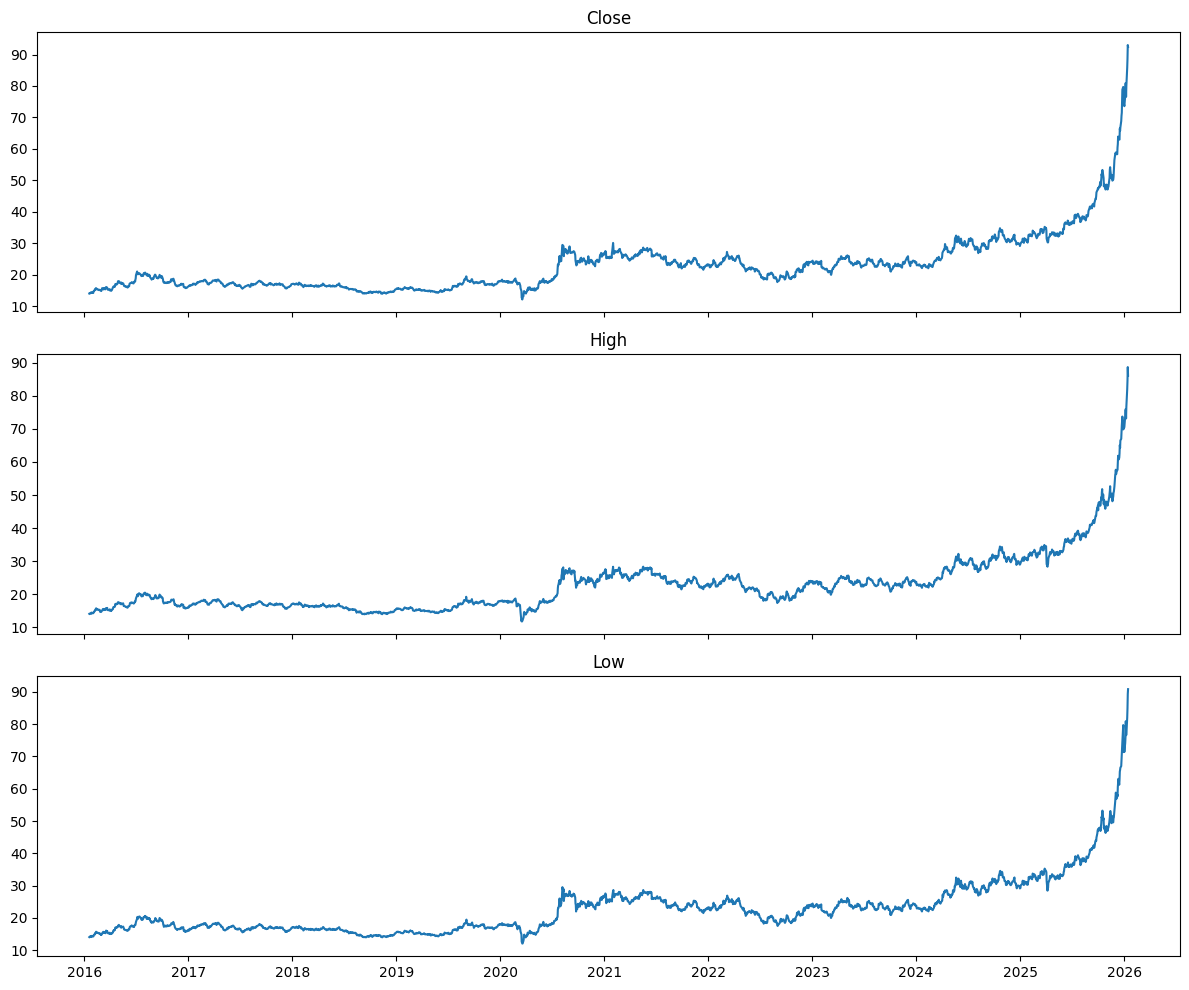

In [142]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

cols = ["Close","High","Low"]

for i, col in enumerate(cols):
    axs[i].plot(data["Date"], data[col])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

Feature Engineering

In [143]:
data['Daily Range'] = data['High'] - data['Low']
data['Daily Return'] = data['Close'] - data['Open']
data['Pct Return'] = (data['Close'] - data['Open']) / data['Open']
data.head()

,Date,Price,Close,High,Low,Open,Year,Daily Range,Daily Return,Pct Return
0,2016-01-19,14.110,14.110,14.065,14.065,3,2016,0.000,11.110,3.703333
1,2016-01-20,14.147,14.147,14.147,14.147,1,2016,0.000,13.147,13.147000
2,2016-01-21,14.083,14.083,14.083,14.083,2,2016,0.000,12.083,6.041500
3,2016-01-22,14.043,14.290,14.043,14.290,7,2016,-0.247,7.290,1.041429
4,2016-01-25,14.240,14.240,14.095,14.095,8,2016,0.000,6.240,0.780000


In [144]:
data = data.sort_values("Date").reset_index(drop=True)

In [145]:
lags = [1, 3, 7, 14, 30]

for lag in lags:
    data[f"close_lag_{lag}"] = data["Close"].shift(lag)

In [146]:
data["pct_return_1"] = data["Close"].pct_change(1)
data["pct_return_7"] = data["Close"].pct_change(7)

In [147]:
data["sma_7"] = data["Close"].rolling(window=7).mean()
data["sma_30"] = data["Close"].rolling(window=30).mean()

In [148]:
data["volatility_7"] = data["Close"].rolling(7).std().shift(1)
data["volatility_30"] = data["Close"].rolling(30).std().shift(1)

In [149]:
data["day_of_year"] = data["Date"].dt.dayofyear
data["doy_sin"] = np.sin(2 * np.pi * data["day_of_year"] / 365)
data["doy_cos"] = np.cos(2 * np.pi * data["day_of_year"] / 365)

In [150]:
#predicting next day Close
data["target"] = data["Close"].shift(-1)
data_model = data.dropna().copy()

In [151]:
data_model.head()

,Date,Price,Close,High,Low,Open,Year,Daily Range,Daily Return,Pct Return,...,pct_return_1,pct_return_7,sma_7,sma_30,volatility_7,volatility_30,day_of_year,doy_sin,doy_cos,target
30,2016-03-02,15.003,15.003,14.760,14.810,809,2016,-0.050,-793.997,-0.981455,...,-0.002460,-0.011595,15.130000,14.932133,0.128059,0.531729,62,0.875892,0.482508,15.330
31,2016-03-03,15.131,15.330,14.920,14.945,678,2016,-0.025,-662.670,-0.977389,...,0.021796,0.006236,15.143571,14.971567,0.139372,0.510410,63,0.884068,0.467359,15.780
32,2016-03-04,15.681,15.780,15.140,15.220,912,2016,-0.080,-896.220,-0.982697,...,0.029354,0.031912,15.213286,15.028133,0.155045,0.493064,64,0.891981,0.452072,15.795
33,2016-03-07,15.623,15.795,15.525,15.570,933,2016,-0.045,-917.205,-0.983071,...,0.000951,0.040171,15.300429,15.078300,0.286712,0.484884,67,0.914128,0.405426,15.750
34,2016-03-08,15.384,15.750,15.365,15.710,906,2016,-0.345,-890.250,-0.982616,...,-0.002849,0.034143,15.374714,15.128633,0.360013,0.483736,68,0.920971,0.389630,15.395


<Axes: >

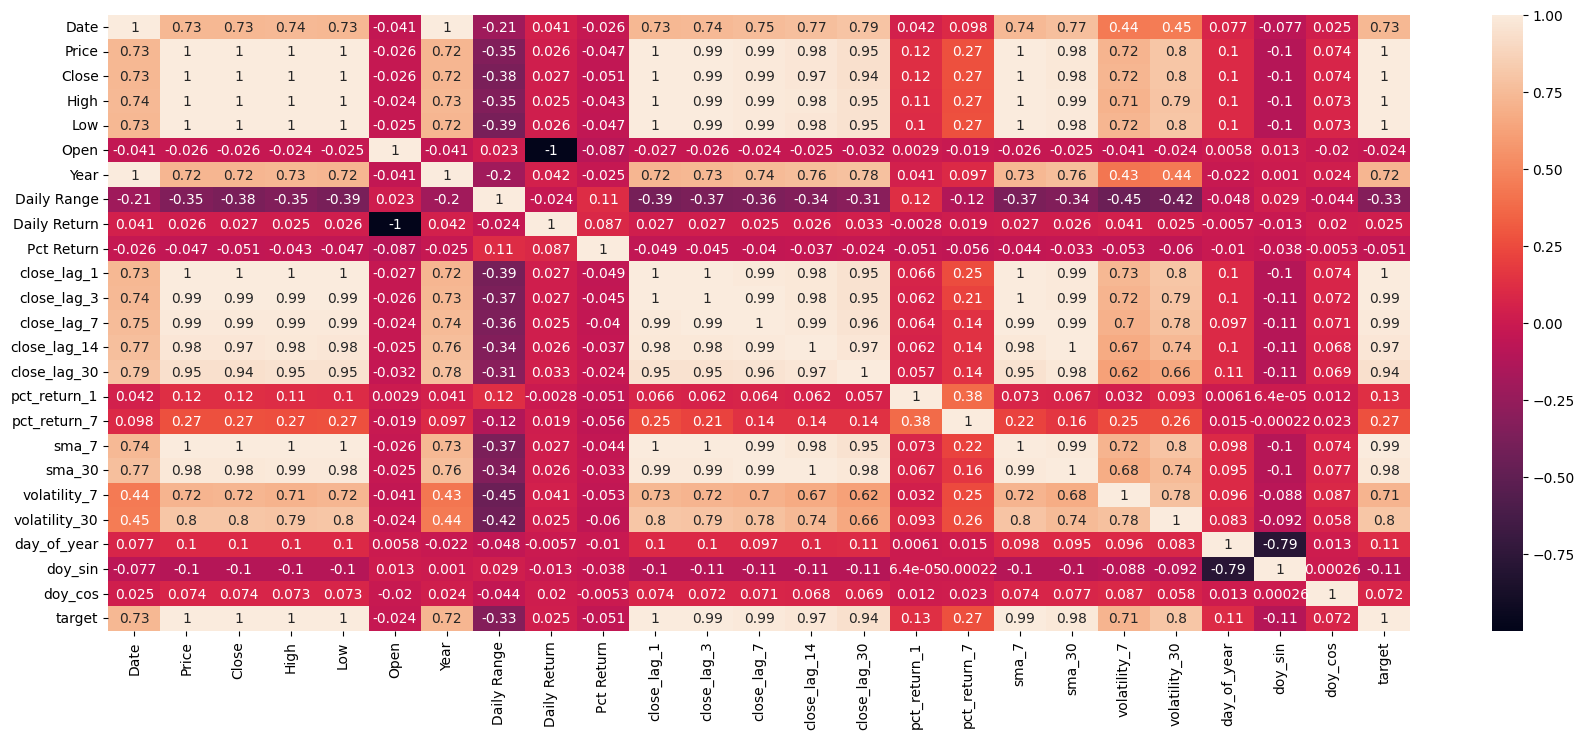

In [152]:
plt.figure(figsize=(21, 8))
corr = data.corr()
sns.heatmap(corr, annot=True)

## 3. Modeling

In [177]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [154]:
split_index = int(len(data_model) * 0.8)

train = data_model.iloc[:split_index]
test  = data_model.iloc[split_index:]

In [155]:
feature_cols = [
    "close_lag_1",
    "close_lag_7",
    "close_lag_30",
    "pct_return_1",
    "pct_return_7",
    "sma_7",
    "sma_30",
    "volatility_7",
    "doy_sin",
    "doy_cos"
]

X_train = train[feature_cols]
y_train = train["target"]

X_test = test[feature_cols]
y_test = test["target"]

In [156]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [157]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
r2 = r2_score(y_test, ridge_pred)

print(f"Ridge -> RMSE: {rmse:.4f} | R²: {r2:.4f}")

Ridge -> RMSE: 1.3507 | R²: 0.9867


In [158]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
best_alpha = None
best_rmse = float("inf")

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print("Best alpha:", best_alpha)
print("Best RMSE:", round(best_rmse, 4))

Best alpha: 0.001
Best RMSE: 1.2839


In [159]:
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": best_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df)

        Feature  Coefficient
0   close_lag_1     3.327093
1   close_lag_7     0.568326
3  pct_return_1     0.336286
4  pct_return_7     0.127773
5         sma_7     0.094200
2  close_lag_30    -0.026289
6        sma_30     0.019267
7  volatility_7    -0.004321
9       doy_cos     0.002921
8       doy_sin    -0.000225


Hyperparameter tuning indicated minimal regularization was optimal, suggesting that although engineered features exhibit multicollinearity, predictive performance remains stable without aggressive coefficient shrinkage.

In [160]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression -> RMSE: {lr_rmse:,.2f} | R²: {lr_r2:.4f}")

Linear Regression -> RMSE: 1.28 | R²: 0.9880


Linear regression achieved the best predictive performance. Although feature multicollinearity was observed, regularization did not improve accuracy, indicating that the autoregressive structure of silver prices dominates the signal and does not require shrinkage for stable forecasting.

In [161]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> RMSE: {rf_rmse:,.2f} | R²: {rf_r2:.4f}")

Random Forest -> RMSE: 14.31 | R²: -0.4969


Tree-based models performed poorly due to their inability to extrapolate beyond the training distribution. As the test period exhibited higher price levels than observed in training, Random Forest regression failed to capture the upward trend, resulting in significant performance degradation.

PREDICTING RETURNS

Log Returns
r_t = log(Close_t) - log(Close_{t-1})

In [162]:
data_model["log_return"] = np.log(data_model["Close"]).diff()
#changing target to previous day log return
data_model["target"] = data_model["log_return"].shift(-1)
data_model.drop(columns='log_return', axis = 1, inplace=True)
data_model_return = data_model.dropna().copy()

In [163]:
split_index = int(len(data_model) * 0.8)

train_return = data_model_return.iloc[:split_index]
test_return  = data_model_return.iloc[split_index:]

In [164]:
feature_cols = [
    "close_lag_1",
    "close_lag_7",
    "close_lag_30",
    "pct_return_1",
    "pct_return_7",
    "sma_7",
    "sma_30",
    "volatility_7",
    "doy_sin",
    "doy_cos"
]

X_train_return = train_return[feature_cols]
y_train_return = train_return["target"]

X_test_return = test_return[feature_cols]
y_test_return = test_return["target"]

In [165]:
scaler = StandardScaler()
X_train_scaled_return = scaler.fit_transform(X_train_return)
X_test_scaled_return  = scaler.transform(X_test_return)

In [166]:
lr = LinearRegression()
lr.fit(X_train_scaled_return, y_train_return)

lr_pred = lr.predict(X_test_scaled_return)
lr_rmse = np.sqrt(mean_squared_error(y_test_return, lr_pred))
lr_r2 = r2_score(y_test_return, lr_pred)

print(f"Linear Regression -> RMSE: {lr_rmse:,.2f} | R²: {lr_r2:.4f}")

Linear Regression -> RMSE: 0.02 | R²: -0.1757


Silver price levels are predictable via persistence, but daily returns exhibit weak predictability consistent with efficient market behavior

In [167]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_return, y_train_return)
rf_pred = rf.predict(X_test_return)

rf_rmse = np.sqrt(mean_squared_error(y_test_return, rf_pred))
rf_r2 = r2_score(y_test_return, rf_pred)

print(f"Random Forest -> RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}")

Random Forest -> RMSE: 0.0592 | R²: -7.8509


In [172]:
data_model_return["direction"] = (data_model_return["target"] > 0).astype(int)
data_model = data_model_return.dropna().copy()

In [173]:
split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test  = data_model.iloc[split_idx:]

In [174]:
feature_cols = [
    "close_lag_1",
    "close_lag_7",
    "close_lag_30",
    "pct_return_1",
    "pct_return_7",
    "volatility_7",
    "doy_sin",
    "doy_cos"
]

X_train = train[feature_cols]
y_train = train["direction"]

X_test = test[feature_cols]
y_test = test["direction"]

In [178]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=400, n_jobs=-1,
                       random_state=42)

In [179]:
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

In [180]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Accuracy: 0.4708
ROC-AUC: 0.4766


While silver price levels were highly predictable due to strong autocorrelation, both return regression and directional classification models failed to outperform random baselines. These findings are consistent with weak-form market efficiency, suggesting limited predictive power from historical price-derived features alone.